In [7]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [1]:
import pandas as pd

# Load final loop data
loop_df = pd.read_csv("merged_loops_with_genes.tsv", sep="\t")

# Load upregulated and downregulated log2fc data
up_df = pd.read_csv("mega_upregulated_withall3_log2fc.tsv", sep="\t")
down_df = pd.read_csv("mega_downregulated_withall3_log2fc.tsv", sep="\t")

# Combine both into a single log2fc table
log2fc_all = pd.concat([up_df, down_df], axis=0)

# Strip whitespace to avoid merge issues
loop_df['gene_symbol'] = loop_df['gene_symbol'].str.strip()
log2fc_all['hgnc_symbol'] = log2fc_all['hgnc_symbol'].str.strip()

# Merge on gene symbol
final_df = loop_df.merge(
    log2fc_all.rename(columns={'hgnc_symbol': 'gene_symbol'}),
    on='gene_symbol',
    how='left'
)

# Save or inspect
#final_df.to_csv("loop_df_with_log2fc.tsv", sep="\t", index=False)
final_df

,tss_chr,tss_start,tss_end,gene_id_x,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,...,delta_E1_anchor1,delta_E1_anchor2,distal_chr,distal_start,distal_end,gene_id_y,gene_symbol,log2fc_exon,log2fc_intron,log2fc_deseq
0,chr16,69754416,69755417,ENST00000562416.1,0,-,chr16,69750000,69755000,2,...,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000562416,NOB1,NaN,NaN,0.673988
1,chr16,69754291,69755292,ENST00000563055.1,0,-,chr16,69750000,69755000,2,...,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000563055,NOB1,NaN,NaN,0.673988
2,chr16,69751752,69752753,ENST00000561677.6,0,-,chr16,69750000,69755000,2,...,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000561677,NOB1,NaN,NaN,0.673988
3,chr16,69754425,69755426,ENST00000268802.10,0,-,chr16,69750000,69755000,2,...,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000268802,NOB1,NaN,NaN,0.673988
4,chr16,69754413,69755414,ENST00000564620.5,0,-,chr16,69750000,69755000,2,...,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000564620,NOB1,NaN,NaN,0.673988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,chr3,124927270,124928271,ENST00000490147.1,0,-,chr3,124922500,124927500,1,...,0.091242,-0.010410,chr3,125582500,125587500,ENST00000490147,MUC13,0.677699,NaN,0.746854
621,chr12,68325609,68326610,ENST00000540476.5,0,-,chr12,68322500,68327500,2,...,NaN,NaN,chr12,67352500,67357500,ENST00000540476,MDM1,NaN,NaN,-0.669286
622,chr12,68322711,68323712,ENST00000538454.2,0,-,chr12,68322500,68327500,2,...,NaN,NaN,chr12,67352500,67357500,ENST00000538454,MDM1,NaN,NaN,-0.669286
623,chr12,68322897,68323898,ENST00000536997.1,0,-,chr12,68322500,68327500,2,...,NaN,NaN,chr12,67352500,67357500,ENST00000536997,MDM1,NaN,NaN,-0.669286


In [2]:
# Show all columns and rows (be careful with huge data)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Then just display it
final_df

,tss_chr,tss_start,tss_end,gene_id_x,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,deg_class,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2,loop_class,source,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,distal_chr,distal_start,distal_end,gene_id_y,gene_symbol,log2fc_exon,log2fc_intron,log2fc_deseq
0,chr16,69754416,69755417,ENST00000562416.1,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000562416,NOB1,NaN,NaN,0.673988
1,chr16,69754291,69755292,ENST00000563055.1,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000563055,NOB1,NaN,NaN,0.673988
2,chr16,69751752,69752753,ENST00000561677.6,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000561677,NOB1,NaN,NaN,0.673988
3,chr16,69754425,69755426,ENST00000268802.10,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000268802,NOB1,NaN,NaN,0.673988
4,chr16,69754413,69755414,ENST00000564620.5,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000564620,NOB1,NaN,NaN,0.673988
5,chr16,69754423,69755424,ENST00000569871.5,0,-,chr16,69750000,69755000,2,upregulated_a2,22141,chr16,69715000,69720000,chr16,69750000,69755000,gained,0.037667,0.037849,0.006960,0.006960,Mutant loop,35000,22141,stable,stable,intra-TAD,rbp1,6.264811,0.529711,0.227124,0.031918,0.4658,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000569871,NOB1,NaN,NaN,0.673988
6,chrX,152830466,152831467,ENST00000440023.5,0,+,chrX,152830000,152835000,1,upregulated_a1,15092,chrX,152830000,152835000,chrX,152870000,152875000,lost,0.025911,0.022190,-0.223654,-0.223654,Control loop,40000,15092,stable,stable,intra-TAD,ctrl,1.729350,11.512398,0.188543,0.022016,0.5256,0.0080,-0.491845,-0.482832,-0.203780,-0.253907,0.009013,-0.050127,chrX,152870000,152875000,ENST00000440023,NSDHL,0.669276,NaN,0.668064
7,chr3,4979731,4980732,ENST00000460806.1,0,+,chr3,4980000,4985000,1,upregulated_a1,16846,chr3,4980000,4985000,chr3,5020000,5025000,lost,0.034674,0.036021,0.055016,0.055016,Control loop,40000,16846,stable,stable,intra-TAD,ctrl,2.545079,0.188342,0.188543,0.035727,0.4609,0.0166,0.462050,0.470472,0.442050,0.345301,0.008422,-0.096749,chr3,5020000,5025000,ENST00000460806,BHLHE40,0.909796,NaN,0.943070
8,chr19,41708125,41709126,ENST00000221992.11,0,+,chr19,41705000,41710000,1,upregulated_a1,3210,chr19,41705000,41710000,chr19,41745000,41750000,shared,0.064997,0.049929,-0.380497,-0.380497,sha

In [5]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

for col in ['log2fc_exon', 'log2fc_intron', 'log2fc_deseq']:
    print(f"\nTukey HSD for {col}")
    df_nonan = final_df[[col, 'status']].dropna()
    tukey = pairwise_tukeyhsd(endog=df_nonan[col], groups=df_nonan['status'], alpha=0.05)
    print(tukey.summary())


Tukey HSD for log2fc_exon
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
gained   lost  -0.0091  0.994 -0.2161 0.1978  False
gained shared   0.3266 0.0029   0.095 0.5581   True
  lost shared   0.3357 0.0001  0.1532 0.5182   True
---------------------------------------------------

Tukey HSD for log2fc_intron
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
gained   lost   0.0426 0.9844 -0.5596 0.6447  False
gained shared   0.7634    0.0  0.3826 1.1442   True
  lost shared   0.7208 0.0096  0.1496  1.292   True
---------------------------------------------------

Tukey HSD for log2fc_deseq
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
gained   lost    0.122 0.2635 -0

In [8]:
for col in ['log2fc_exon', 'log2fc_intron', 'log2fc_deseq']:
    print(f"\nANOVA for {col}")
    model = ols(f'{col} ~ C(status)', data=final_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)


ANOVA for log2fc_exon
              sum_sq     df          F    PR(>F)
C(status)   5.896348    2.0  10.175577  0.000055
Residual   76.488821  264.0        NaN       NaN

ANOVA for log2fc_intron
              sum_sq    df          F    PR(>F)
C(status)  11.344505   2.0  13.230889  0.000011
Residual   33.439606  78.0        NaN       NaN

ANOVA for log2fc_deseq
               sum_sq     df         F    PR(>F)
C(status)    2.901706    2.0  3.903241  0.020959
Residual   146.823317  395.0       NaN       NaN


/tmp/ipykernel_2679355/1562164381.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=col, data=final_df, palette="Set2")


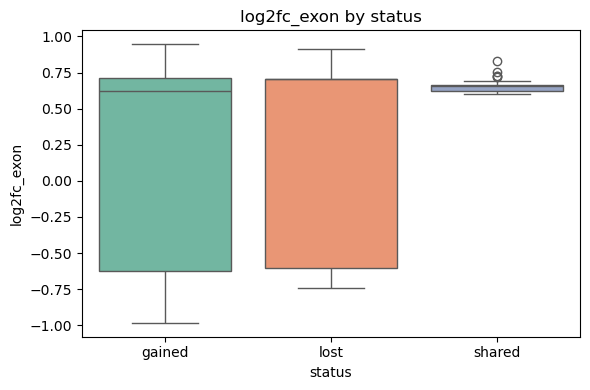

/tmp/ipykernel_2679355/1562164381.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=col, data=final_df, palette="Set2")


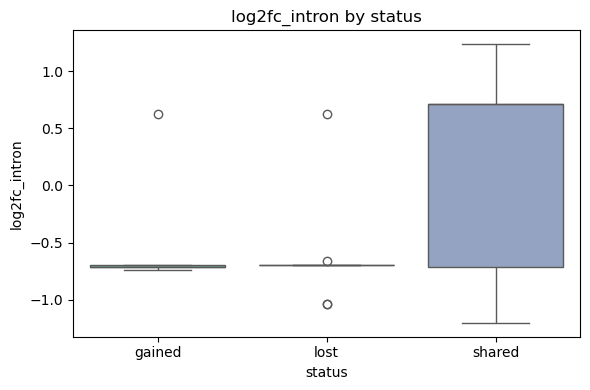

/tmp/ipykernel_2679355/1562164381.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=col, data=final_df, palette="Set2")


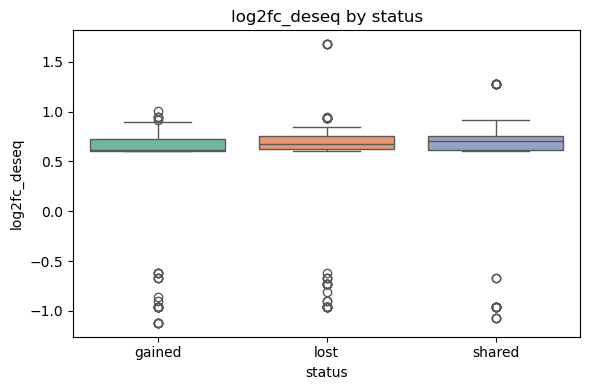

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['log2fc_exon', 'log2fc_intron', 'log2fc_deseq']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='status', y=col, data=final_df, palette="Set2")
    plt.title(f"{col} by status")
    plt.tight_layout()
    plt.show()

In [ ]:
for col in ['log2fc_exon', 'log2fc_intron', 'log2fc_deseq']:
    print(f"\nANOVA for {col}")
    model = ols(f'{col} ~ C(log2FC)', data=final_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

In [15]:
from scipy.stats import spearmanr, pearsonr

# Drop NAs per comparison
df_exon = final_df.dropna(subset=['log2fc_exon', 'log2FC'])
df_intron = final_df.dropna(subset=['log2fc_intron', 'log2FC'])
df_deseq = final_df.dropna(subset=['log2fc_deseq', 'log2FC'])

# Spearman correlations
rho_exon, p_exon = spearmanr(df_exon['log2fc_exon'], df_exon['log2FC'])
rho_intron, p_intron = spearmanr(df_intron['log2fc_intron'], df_intron['log2FC'])
rho_deseq, p_deseq = spearmanr(df_deseq['log2fc_deseq'], df_deseq['log2FC'])

print("Exon vs loop:    Spearman =", rho_exon, "p =", p_exon)
print("Intron vs loop:  Spearman =", rho_intron, "p =", p_intron)
print("DESeq vs loop:   Spearman =", rho_deseq, "p =", p_deseq)

Exon vs loop:    Spearman = 0.09885468219269805 p = 0.10703373816475864
Intron vs loop:  Spearman = -0.37735010818518583 p = 0.000515272030578204
DESeq vs loop:   Spearman = -0.10114897415892281 p = 0.04372225716903569
